# Model Initialization - Single `.mo` File

This notebook initializes one dynamic Modelica model from its auxiliary model.

It loads the model and its auxiliary from `models/`, simulates the auxiliary to compute the initialization values, applies them to a copy of the model, and saves the initialized model to `outputs/`.

In [1]:
include("../scripts/dictionaries.jl")
include("../scripts/helpers.jl")
using .WorkflowHelpers
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Input and output directories
MODEL_DIR = abspath("models")
OUTPUT_DIR = abspath("outputs")
mkpath(OUTPUT_DIR)

# 2. Select the model to initialize
MODEL = "Demo_BESS"

# 3. Path to the selected dynamic case file
MODEL_FILE_PATH = joinpath(MODEL_DIR, MODEL * ".mo")

# 4. Name and path of the initialized dynamic case file (written under outputs/)
INITIALIZED_MODEL = MODEL * "_initialized"
INITIALIZED_FILE_PATH = joinpath(OUTPUT_DIR, INITIALIZED_MODEL * ".mo")

# 5. Path to the auxiliary file (input, from BuildAux)
AUX_MODEL = MODEL * "_auxiliary"
AUX_FILE_PATH = joinpath(MODEL_DIR, AUX_MODEL * ".mo")

# 6. Modelica Standard Library
OMLIB_DIR = joinpath(homedir(), ".openmodelica", "libraries")
ENV["OPENMODELICALIBRARY"] = OMLIB_DIR
MODELICA_PKG_PATH = joinpath(OMLIB_DIR, "Modelica 3.2.3+maint.om", "package.mo")

# 7. Dynawo Modelica library from this repo
DYNAWO_PKG_PATH = abspath("../dynawo_library/Dynawo/package.mo")

# 8. INIT model selection for components with multiple INIT profiles (leave empty for default).
INIT_MODEL_BY_COMPONENT = Dict{String, String}()

# 9. Variable to plot after the initialized simulation
# PLOT_VARIABLE = "generatorSynchronous.terminal.i.re"  # SMIB option
PLOT_VARIABLE = "BESS.terminal.V.im"  # Demo_BESS option
# PLOT_VARIABLE = "PV.measurements.PPu" # Demo_PVCurrent option
# PLOT_VARIABLE = "deltaFrequency"  # Demo_DIGrid option

"BESS.terminal.V.im"

## Load and Validate the Models

The dynamic model and its auxiliary are loaded and checked, and the user configuration is validated against the dynamic model, before any changes are made.

In [2]:
# 1. Load the dynamic model and validate the configuration against it
SourceOMC = OMJulia.OMCSession()
omc_call(SourceOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(SourceOMC, "loadModel(Complex)")
omc_call(SourceOMC, "loadModel(ModelicaServices)")
omc_call(SourceOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(SourceOMC, "loadFile(\"$MODEL_FILE_PATH\")")
check_user_configuration_single(SourceOMC;
    model = MODEL,
    init_model_by_component = INIT_MODEL_BY_COMPONENT,
)

# 2. Load the auxiliary model
AuxOMC = OMJulia.OMCSession()
omc_call(AuxOMC, "loadFile(\"$MODELICA_PKG_PATH\")")
omc_call(AuxOMC, "loadModel(Complex)")
omc_call(AuxOMC, "loadModel(ModelicaServices)")
omc_call(AuxOMC, "loadFile(\"$DYNAWO_PKG_PATH\")")
omc_call(AuxOMC, "loadFile(\"$AUX_FILE_PATH\")")
println("Checking the auxiliary model...")
chk_aux = sendExpression(AuxOMC, "checkModel($AUX_MODEL)", parsed=false)
println(chk_aux)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.BTPzkqXWFL"


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.LEkMDNbW46"


Configuration checked successfully


Checking the auxiliary model...


"Check of Demo_BESS_auxiliary completed successfully.
Class Demo_BESS_auxiliary has 83 equation(s) and 83 variable(s).
23 of these are trivial equation(s)."



## Extract Initialization Values

The auxiliary model is simulated, and its outputs provide the initialization values to apply to the dynamic model.

In [3]:
# 1. Build and simulate the auxiliary model
ModelicaSystem(AuxOMC, AUX_FILE_PATH, AUX_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(AuxOMC, resultfile = AUX_MODEL * "_res.mat")

# 2. Get the dynamic model components that need initialization
components = get_all_components(SourceOMC, MODEL)
initializable_components = get_initializable_components(components, INIT_MODEL_BY_COMPONENT)

# 3. Extract initialization values from the auxiliary model
init_values_by_component = extract_all_initialization_values(AuxOMC, components, INIT_MODEL_BY_COMPONENT)

Dict{String, Dict{String, Float64}} with 1 entry:
  "BESS" => Dict("uPcc0Pu.re"=>0.540302, "uPcc0Pu.im"=>0.841471, "PF0"=>1.0, "Q…

## Build Initialized Model

A copy of the dynamic model is populated with the extracted values and saved as the initialized model in `outputs/`.

In [4]:
sendExpression(SourceOMC, "deleteClass($INITIALIZED_MODEL)")
omc_call(SourceOMC, "copyClass($MODEL, \"$INITIALIZED_MODEL\")")

apply_initialization_modifiers!(SourceOMC, INITIALIZED_MODEL, initializable_components, init_values_by_component, INIT_MODEL_BY_COMPONENT)

omc_call(SourceOMC, "saveModel(\"$INITIALIZED_FILE_PATH\", $INITIALIZED_MODEL)")
println("Wrote initialized model: ", INITIALIZED_FILE_PATH)

Wrote initialized model: /home/clarafercas/dynawo-notebooks/src/julia_openmodelica/Initialization/outputs/Demo_BESS_initialized.mo


## Validate Initialized Model

The initialized model is loaded independently and simulated to verify that the final output can run.

In [5]:
InitializedOMC = OMJulia.OMCSession()
omc_call(InitializedOMC, "loadModel(Complex)")
omc_call(InitializedOMC, "loadModel(ModelicaServices)")
ModelicaSystem(InitializedOMC, INITIALIZED_FILE_PATH, INITIALIZED_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
println("Checking the initialized model...")
chk_init = sendExpression(InitializedOMC, "checkModel($INITIALIZED_MODEL)", parsed=false)
println(chk_init)

simflags = simulation_flags_without_log_stats(InitializedOMC, INITIALIZED_MODEL)
initialized_resultfile_prefix = INITIALIZED_MODEL

sim_result = sendExpression(
    InitializedOMC,
    "simulate($INITIALIZED_MODEL, outputFormat=\"csv\", fileNamePrefix=\"$initialized_resultfile_prefix\", simflags=\"$simflags\")",
    parsed = false,
)

println(sim_result)

initialized_resultfile = joinpath(
    getWorkDirectory(InitializedOMC),
    initialized_resultfile_prefix * "_res.csv",
)

[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.O26Bmqg2ac"


Checking the initialized model...


"Check of Demo_BESS_initialized completed successfully.
Class Demo_BESS_initialized has 673 equation(s) and 673 variable(s).
452 of these are trivial equation(s)."



record SimulationResult
    resultFile = "/tmp/jl_BCWQTZ/Demo_BESS_initialized_res.csv",
    simulationOptions = "startTime = 0.0, stopTime = 3.0, numberOfIntervals = 3000, tolerance = 1e-5, method = 'dassl', fileNamePrefix = 'Demo_BESS_initialized', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-s=ida -maxIntegrationOrder=2 -nls=kinsol -noHomotopyOnFirstTry -noRestart -noRootFinding -initialStepSize=0.00001 -maxStepSize=10'",
    messages = "LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
",
    timeFrontend = 0.055108841000000006,
    timeBackend = 0.645606245,
    timeSimCode = 0.051844850000000005,
    timeTemplates = 0.21562185900000003,
    timeCompile = 1.797724848,
    timeSimulation = 0.426257588,
    timeTotal = 3.192350255
end SimulationResult;



"/tmp/jl_BCWQTZ/Demo_BESS_initialized_res.csv"

## Optional: Plot Simulation Result

The final cell is an optional example of visualizing a variable from the initialized-model simulation result.

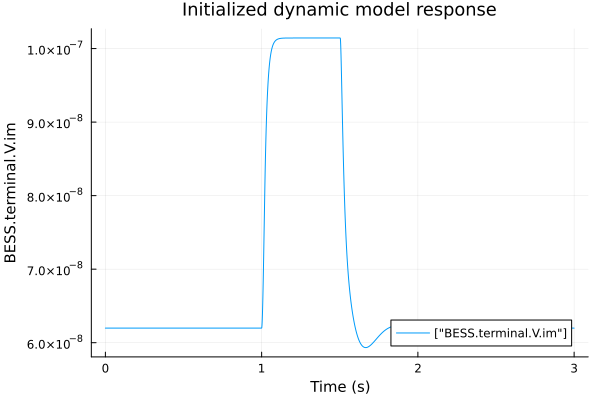

In [6]:
initialized_df = DataFrame(CSV.File(initialized_resultfile))
PLOT_VARIABLE in names(initialized_df) ||
    error("PLOT_VARIABLE \"$PLOT_VARIABLE\" is not a variable in the simulation result.")

p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized dynamic model response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)